[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **CV Nano Variant Model Comparision**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)

This notebook benchmarks a nano vision model on a sample video, measuring inference performance and resource usage. It also visualizes annotated detections for a representative frame and processes the model across video frames.

---
## 1. Install Packages

Install the libraries and CUDA-enabled PyTorch dependencies required for model loading, video processing, benchmarking, and visualization.

In [ ]:
# Packages installation
# !uv pip install ultralytics rfdetr opencv-python pandas matplotlib tqdm

# RTX 5060 supported torch with CUDA
# !uv pip install --force-reinstall torch torchvision --index-url https://download.pytorch.org/whl/cu128

---
## 2. Import Libraries

Import standard-library, scientific-computing, computer-vision, and model-serving utilities used throughout the benchmark.

In [5]:
import time
import gc
import os
import subprocess
from dataclasses import dataclass, asdict
from typing import Optional

import cv2
import numpy as np
import pandas as pd
import psutil
import torch
import matplotlib.pyplot as plt

---
## 3. Configure Benchmark Parameters

Define the reusable benchmark configuration, including image size, confidence threshold, IoU threshold, and execution device.

In [6]:
@dataclass
class BenchmarkConfig:
    imgsz: int = 640
    conf: float = 0.25
    iou: float = 0.45
    device: str = "cuda"
    warmup_runs: int = 5
    benchmark_runs: int = 20
    
config = BenchmarkConfig(
    imgsz=640,
    conf=0.25,
    iou=0.45,
    device="cuda",
    warmup_runs=5,
    benchmark_runs=20,
)

---
## 4. Define Model Configurations

Declare the models to benchmark along with their framework, weights, and runtime settings.

In [7]:
MODEL_CONFIGS = {
    "YOLO26-N": {
        "type": "ultralytics",
        "weights": "models/yolo26n.pt",
        "download_source": "yolo26n.pt",
    },

    "YOLOv12-N": {
        "type": "ultralytics",
        "weights": "models/yolo12n.pt",
        "download_source": "yolo12n.pt",
    },

    "RF-DETR-Small": {
        "type": "rf-detr",
        "weights": "models/rf-detr-small.pth",
        "download_source": "rf-detr-small.pth",
    },
}

---
## 5. Measure GPU Memory

Create a helper that reads PyTorch CUDA memory statistics so resource usage can be reported alongside inference results.

In [8]:
def get_pytorch_gpu_memory():
    """
    Get PyTorch CUDA memory statistics.
    Returns model-specific GPU memory usage.
    """
    if torch.cuda.is_available():
        allocated_mb = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved_mb = torch.cuda.memory_reserved() / (1024 ** 2)
        peak_allocated_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        peak_reserved_mb = torch.cuda.max_memory_reserved() / (1024 ** 2)
        
        return {
            "torch_allocated_mb": allocated_mb,
            "torch_reserved_mb": reserved_mb,
            "torch_peak_allocated_mb": peak_allocated_mb,
            "torch_peak_reserved_mb": peak_reserved_mb,
        }
    else:
        return {
            "torch_allocated_mb": 0,
            "torch_reserved_mb": 0,
            "torch_peak_allocated_mb": 0,
            "torch_peak_reserved_mb": 0,
        }


def get_process_resources():
    """
    Get current Python process resource usage.
    Returns process-specific RAM usage.
    """
    process = psutil.Process(os.getpid())
    memory_info = process.memory_info()
    
    return {
        "process_ram_mb": memory_info.rss / (1024 ** 2),
    }


def measure_resources():
    """
    Measure both GPU memory and process resources.
    """
    gpu_memory = get_pytorch_gpu_memory()
    process_resources = get_process_resources()
    
    return {
        **gpu_memory,
        **process_resources,
    }


def clear_gpu_memory():
    """
    Clear GPU memory cache and collect garbage.
    """
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def get_video_frame(
    video_path,
    timestamp_sec
):
    """
    Extract one frame at a given timestamp.
    """
    cap = cv2.VideoCapture(video_path)

    cap.set(
        cv2.CAP_PROP_POS_MSEC,
        timestamp_sec * 1000
    )

    success, frame = cap.read()

    cap.release()

    if not success:
        raise RuntimeError(
            f"Could not read frame at {timestamp_sec}s"
        )

    return frame


def show_frame(
    frame,
    figsize=(16, 9)
):
    """
    Display a frame using matplotlib.
    """
    plt.figure(figsize=figsize)

    plt.imshow(
        cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.axis("off")
    plt.show()

---
## 6. Load Models

Implement model loading for the configured frameworks and place each model on the selected compute device.

In [9]:
def load_model(model_name, model_config, device="cuda"):
    """
    Load a model, downloading and caching its weights when needed.

    Returns
    -------
    model
    """

    import shutil
    from pathlib import Path

    model_type = model_config["type"]
    weights_path = Path(model_config["weights"])
    download_source = model_config.get("download_source")

    if model_type == "ultralytics":

        from ultralytics import YOLO

        if weights_path.exists():
            weights = str(weights_path)
        else:
            if not download_source:
                raise FileNotFoundError(
                    f"Weights not found for {model_name}: {weights_path}. "
                    "Set download_source in MODEL_CONFIGS."
                )

            print(f"Downloading {model_name} weights...")
            downloaded_model = YOLO(download_source)
            downloaded_weights = getattr(
                downloaded_model,
                "ckpt_path",
                None,
            )

            if not downloaded_weights or not Path(downloaded_weights).exists():
                raise FileNotFoundError(
                    f"Could not locate downloaded weights for {model_name}."
                )

            weights_path.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(downloaded_weights, weights_path)
            print(f"Stored weights at {weights_path}")
            weights = str(weights_path)

        model = YOLO(weights)

        if device == "cuda":
            model.to("cuda")

        return model

    elif model_type == "rf-detr":

        from rfdetr import RFDETRSmall

        if not weights_path.exists() and not download_source:
            raise FileNotFoundError(
                f"Weights not found for {model_name}: {weights_path}. "
                "Set download_source in MODEL_CONFIGS."
            )

        weights = (
            str(weights_path)
            if weights_path.exists()
            else download_source
        )

        model = RFDETRSmall(
            pretrain_weights=weights
        )

        return model

    else:
        raise ValueError(
            f"Unsupported model type: {model_type}"
        )

---
## 7. Warm Up Models

Warm up each loaded model with a representative frame so one-time initialization does not distort the benchmark measurements.

In [10]:
def warmup_model(
    model,
    frame,
    model_name,
    config
):
    """
    Run warm-up inference before measuring performance.
    """

    for _ in range(config.warmup_runs):

        run_inference(
            model=model,
            frame=frame,
            model_name=model_name,
            config=config,
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

---
## 8. Run Inference

Run a single inference pass for the selected model and frame, returning the raw prediction and timing information needed downstream.

In [11]:
def run_inference(
    model,
    frame,
    model_name,
    config
):
    """
    Run inference on a single BGR frame.

    Returns:
        Model-specific prediction object.
    """

    if model_name in ["YOLO26-N", "YOLOv12-N"]:

        results = model.predict(
            source=frame,
            imgsz=config.imgsz,
            conf=config.conf,
            iou=config.iou,
            device=config.device,
            verbose=False,
        )

        return results

    elif model_name == "RF-DETR-Small":

        # RF-DETR expects RGB images and returns supervision.Detections.
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return model.predict(
            rgb_frame,
            threshold=config.conf,
            shape=(config.imgsz, config.imgsz),
        )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

---
## 9. Measure Inference Latency

Measure repeated inference timings for a model and frame to produce stable latency statistics for comparison.

In [12]:
def measure_latency(
    model,
    frame,
    model_name,
    config
):
    """
    Measure inference latency over multiple runs.
    """

    latencies = []

    for _ in range(config.benchmark_runs):

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.perf_counter()

        result = run_inference(
            model=model,
            frame=frame,
            model_name=model_name,
            config=config,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.perf_counter()

        latency_ms = (end - start) * 1000

        latencies.append(latency_ms)

    latencies = np.array(latencies)

    return {
        "latency_mean_ms": latencies.mean(),
        "latency_p50_ms": np.percentile(latencies, 50),
        "latency_p95_ms": np.percentile(latencies, 95),
        "latency_min_ms": latencies.min(),
        "latency_max_ms": latencies.max(),
        "fps": 1000 / latencies.mean(),
        "latencies": latencies,
        "last_result": result,
    }

---
## 10. Count Detections

Count the detections returned by YOLO results so detection totals can be included in benchmark summaries.

In [13]:
def count_yolo_detections(results):

    if results is None or len(results) == 0:
        return 0

    result = results[0]

    if result.boxes is None:
        return 0

    return len(result.boxes)


def count_rfdetr_detections(detections):
    """Count detections returned by RF-DETR."""
    if detections is None:
        return 0

    if isinstance(detections, list):
        if not detections:
            return 0
        detections = detections[0]

    return len(detections.xyxy)


def count_detections(model_name, results):
    """Count detections for either supported result format."""
    if model_name in ["YOLO26-N", "YOLOv12-N"]:
        return count_yolo_detections(results)

    if model_name == "RF-DETR-Small":
        return count_rfdetr_detections(results)

    return 0

---
## 11. Draw Benchmark Overlay

Build an overlay that presents timing, detection, and resource metrics directly on an annotated video frame.

In [14]:
def draw_benchmark_overlay(
    frame,
    model_name,
    benchmark,
    resources,
    process_resources,
    detection_count=0,
    frame_timestamp=None,
    font_scale=2.0,
    thickness=3,
    line_spacing=18,
    padding=20,
    alpha=0.75,
):
    """
    Draw benchmark information with:
    - Different color for each line
    - Black semi-transparent background
    - Extra spacing between lines
    """

    output = frame.copy()

    # ---------------------------------------------------------
    # Text + individual colors
    # ---------------------------------------------------------
    lines = [
        (
            f"MODEL: {model_name}",
            (0, 255, 255),      # Yellow
        ),
        (
            f"Timestamp: {frame_timestamp:.2f}s"
            if frame_timestamp is not None
            else None,
            (255, 255, 255),    # White
        ),
        None,  # Blank line
        (
            f"Detections: {detection_count}",
            (0, 255, 0),        # Green
        ),
        (
            f"FPS: {benchmark['fps']:.2f}",
            (0, 255, 0),        # Green
        ),
        (
            f"Latency: {benchmark['latency_mean_ms']:.2f} ms",
            (0, 255, 255),      # Yellow
        ),
        (
            f"P50: {benchmark['latency_p50_ms']:.2f} ms",
            (255, 165, 0),      # Orange
        ),
        (
            f"P95: {benchmark['latency_p95_ms']:.2f} ms",
            (0, 165, 255),      # Orange-ish
        ),
        None,  # Blank line
        (
            f"VRAM Allocated: {resources['torch_allocated_mb']:.0f} MB",
            (255, 255, 0),      # Cyan
        ),
        (
            f"VRAM Peak: {resources['torch_peak_allocated_mb']:.0f} MB",
            (255, 255, 0),      # Cyan
        ),
        None,  # Blank line
        (
            f"Process RAM: {process_resources['process_ram_mb']:.0f} MB",
            (0, 255, 128),      # Green/Cyan
        ),
    ]

    # Remove optional None lines
    lines = [
        line
        for line in lines
        if line is not None
    ]

    # ---------------------------------------------------------
    # Calculate background size
    # ---------------------------------------------------------
    font = cv2.FONT_HERSHEY_SIMPLEX

    font_thickness = thickness

    text_sizes = [
        cv2.getTextSize(
            text,
            font,
            font_scale,
            font_thickness,
        )[0]
        for text, _ in lines
    ]

    max_width = max(
        width
        for width, height in text_sizes
    )

    text_height = max(
        height
        for width, height in text_sizes
    )

    line_height = text_height + line_spacing

    panel_width = max_width + (2 * padding)

    panel_height = (
        len(lines) * line_height
        + (2 * padding)
    )

    # ---------------------------------------------------------
    # Black semi-transparent background
    # ---------------------------------------------------------
    overlay = output.copy()

    cv2.rectangle(
        overlay,
        (0, 0),
        (panel_width, panel_height),
        (0, 0, 0),
        -1,
    )

    output = cv2.addWeighted(
        overlay,
        alpha,
        output,
        1 - alpha,
        0,
    )

    # ---------------------------------------------------------
    # Draw each line
    # ---------------------------------------------------------
    x = padding
    y = padding + text_height

    for item in lines:
        if item is None:
            # Skip blank line in rendering
            y += line_height
        else:
            text, color = item
            
            if text is not None:
                cv2.putText(
                    output,
                    text,
                    (x, y),
                    font,
                    font_scale,
                    color,
                    thickness,
                    cv2.LINE_AA,
                )

                y += line_height

    return output

---
## 12. Draw YOLO Detections

Render YOLO bounding boxes and labels on a frame so detected objects can be inspected visually.

In [15]:
def draw_yolo_detections(
    frame,
    results
):
    """
    Draw YOLO bounding boxes.
    """

    if results is None or len(results) == 0:
        return frame

    result = results[0]

    annotated = result.plot()

    return annotated


def draw_rfdetr_detections(
    frame,
    detections,
    class_names=None,
):
    """Draw RF-DETR supervision.Detections on a BGR frame."""
    if detections is None:
        return frame

    if isinstance(detections, list):
        if not detections:
            return frame
        detections = detections[0]

    class_names = class_names or {}

    for box, confidence, class_id in zip(
        detections.xyxy,
        detections.confidence,
        detections.class_id,
    ):
        x1, y1, x2, y2 = [int(value) for value in box]
        class_id = int(class_id)
        label = class_names.get(class_id, str(class_id))
        text = f"{label} {float(confidence):.2f}"

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2,
        )

        text_origin = (x1, max(20, y1 - 8))
        cv2.putText(
            frame,
            text,
            text_origin,
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    return frame

---
## 13. Annotate Frames

Combine detection rendering and benchmark metrics to produce a complete annotated frame for display or video output.

In [16]:
def annotate_frame(
    frame,
    model_name,
    inference_result,
    benchmark,
    resources,
    process_resources,
    detection_count=0,
    timestamp=None,
):
    """
    Create final annotated frame.
    """

    output = frame.copy()

    if model_name in ["YOLO26-N", "YOLOv12-N"]:

        output = draw_yolo_detections(
            output,
            inference_result
        )

    elif model_name == "RF-DETR-Small":

        output = draw_rfdetr_detections(
            output,
            inference_result,
        )

    output = draw_benchmark_overlay(
        frame=output,
        model_name=model_name,
        benchmark=benchmark,
        resources=resources,
        process_resources=process_resources,
        detection_count=detection_count,
        frame_timestamp=timestamp,
    )

    return output

---
## 14. Benchmark a Single Model

Coordinate model warm-up, inference, latency measurement, resource collection, and frame annotation for one benchmark run.

In [17]:
def benchmark_single_model(
    model_name,
    model_config,
    frame,
    config,
    timestamp=None,
):
    """
    Load, warm up and benchmark ONE model on ONE frame.
    """

    clear_gpu_memory()

    print(f"Loading {model_name}...")

    load_start = time.perf_counter()

    model = load_model(
        model_name=model_name,
        model_config=model_config,
        device=config.device,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    load_time = time.perf_counter() - load_start

    print(
        f"{model_name} loaded in "
        f"{load_time:.2f}s"
    )

    print("Warming up...")

    warmup_model(
        model=model,
        frame=frame,
        model_name=model_name,
        config=config,
    )

    # Reset peak memory statistics after warmup
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    print("Benchmarking...")

    # Measure process resources before benchmarking
    process_resources_before = get_process_resources()
    gpu_memory_before = get_pytorch_gpu_memory()

    benchmark = measure_latency(
        model=model,
        frame=frame,
        model_name=model_name,
        config=config,
    )

    # Measure process resources after benchmarking
    process_resources_after = get_process_resources()
    gpu_memory_after = get_pytorch_gpu_memory()

    benchmark["model_load_time_s"] = load_time
    detection_count = count_detections(
        model_name,
        benchmark["last_result"],
    )

    # Add memory and process metrics to benchmark results
    benchmark.update(gpu_memory_after)
    benchmark.update(process_resources_after)
    benchmark["detection_count"] = detection_count

    annotated = annotate_frame(
        frame=frame,
        model_name=model_name,
        inference_result=benchmark["last_result"],
        benchmark=benchmark,
        resources=gpu_memory_after,
        process_resources=process_resources_after,
        detection_count=detection_count,
        timestamp=timestamp,
    )

    return {
        "model_name": model_name,
        "annotated_frame": annotated,
        "benchmark": benchmark,
        "process_resources_before": process_resources_before,
        "process_resources_after": process_resources_after,
        "gpu_memory_before": gpu_memory_before,
        "gpu_memory_after": gpu_memory_after,
        "model": model,
    }

---
## 15. Extract a Video Frame

Load a representative frame from the sample video at a chosen timestamp for the single-frame benchmark.

In [18]:
frame = get_video_frame(
    video_path="video/sample_1.mp4",
    timestamp_sec=10
)


---
## 16. Benchmark a Single Frame

Run the configured YOLO model on the extracted frame and collect its performance and resource metrics.

In [22]:
result = benchmark_single_model(
    model_name="YOLO26-N",
    model_config=MODEL_CONFIGS["YOLOv12-N"],
    frame=frame,
    config=config,
    timestamp=10,
)

Loading YOLO26-N...
YOLO26-N loaded in 0.05s
Warming up...
Benchmarking...


---
## 17. Display Annotated Results

Display the benchmarked frame with its detections and performance overlay for a visual sanity check.

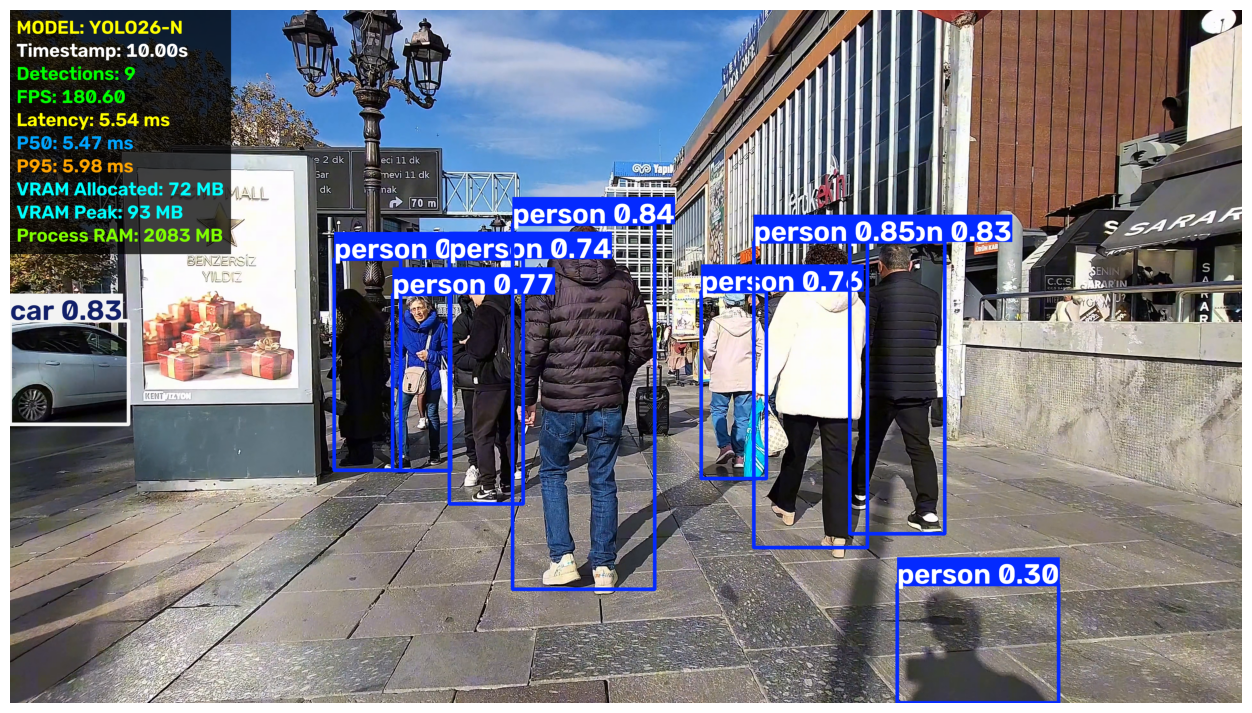

In [23]:
show_frame(
    result["annotated_frame"]
)

---
## 18. Benchmark a Video

Process the sample video with the configured model to measure performance across multiple frames and save the resulting benchmark data.

In [24]:
def benchmark_model_on_video(
    model_name,
    model_config,
    video_path,
    config,
    start_time=0,
    duration=None,
    output_dir="results",
    save_annotated_frames=False,
    save_metrics=True,
    save_result_video=True,
    output_video_path=None,
):
    import json
    from datetime import datetime

    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, "frames"), exist_ok=True)

    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    start_frame = max(0, int(start_time * fps))

    if duration is not None:
        end_frame = min(
            int((start_time + duration) * fps),
            total_frames,
        )
    else:
        end_frame = total_frames

    if start_frame >= end_frame:
        cap.release()
        raise ValueError("The selected video range contains no frames.")

    if output_video_path is None:
        output_video_path = os.path.join(
            output_dir,
            f"{model_name}_annotated_{run_timestamp}.mp4",
        )

    video_writer = None

    if save_result_video:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        video_writer = cv2.VideoWriter(
            output_video_path,
            fourcc,
            fps,
            (width, height),
        )

        if not video_writer.isOpened():
            cap.release()
            raise RuntimeError(
                f"Could not create output video: {output_video_path}"
            )

    frame_metrics = []

    print(f"Processing video: {video_path}")
    print(f"Model: {model_name}")
    print(f"Frames: {start_frame} to {end_frame}")

    clear_gpu_memory()
    model = load_model(model_name, model_config, config.device)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    ret, warmup_frame = cap.read()
    if ret:
        warmup_model(model, warmup_frame, model_name, config)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    for frame_number in range(start_frame, end_frame):
        ret, frame = cap.read()

        if not ret:
            break

        timestamp = frame_number / fps

        resources_before = get_process_resources()
        gpu_before = get_pytorch_gpu_memory()

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        inference_start = time.perf_counter()
        result = run_inference(
            model,
            frame,
            model_name,
            config,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        inference_time_ms = (
            time.perf_counter() - inference_start
        ) * 1000

        resources_after = get_process_resources()
        gpu_after = get_pytorch_gpu_memory()

        fps_instant = (
            1000 / inference_time_ms
            if inference_time_ms > 0
            else 0
        )

        detection_count = count_detections(model_name, result)

        frame_metric = {
            "frame_number": frame_number,
            "timestamp": timestamp,
            "inference_time_ms": inference_time_ms,
            "fps_instant": fps_instant,
            "detection_count": detection_count,
            "process_ram_before_mb": resources_before["process_ram_mb"],
            "process_ram_after_mb": resources_after["process_ram_mb"],
            "gpu_allocated_before_mb": gpu_before["torch_allocated_mb"],
            "gpu_allocated_after_mb": gpu_after["torch_allocated_mb"],
            "gpu_peak_after_mb": gpu_after["torch_peak_allocated_mb"],
        }

        frame_metrics.append(frame_metric)

        annotated_frame = annotate_frame(
            frame=frame,
            model_name=model_name,
            inference_result=result,
            benchmark={
                "fps": fps_instant,
                "latency_mean_ms": inference_time_ms,
                "latency_p50_ms": inference_time_ms,
                "latency_p95_ms": inference_time_ms,
            },
            resources=gpu_after,
            process_resources=resources_after,
            detection_count=detection_count,
            timestamp=timestamp,
        )

        if save_result_video:
            video_writer.write(annotated_frame)

        if save_annotated_frames:
            frame_filename = os.path.join(
                output_dir,
                "frames",
                f"{model_name}_frame_{frame_number:06d}.jpg",
            )
            cv2.imwrite(frame_filename, annotated_frame)

        if len(frame_metrics) % 10 == 0:
            print(
                f"Processed {len(frame_metrics)}/"
                f"{end_frame - start_frame} frames"
            )

    cap.release()

    if video_writer is not None:
        video_writer.release()

    if frame_metrics:
        inference_times = [
            item["inference_time_ms"]
            for item in frame_metrics
        ]
        fps_values = [
            item["fps_instant"]
            for item in frame_metrics
        ]
        detection_counts = [
            item["detection_count"]
            for item in frame_metrics
        ]

        summary = {
            "model_name": model_name,
            "video_path": video_path,
            "output_video_path": (
                output_video_path
                if save_result_video
                else None
            ),
            "total_frames_processed": len(frame_metrics),
            "start_time": start_time,
            "duration": duration,
            "avg_inference_time_ms": float(np.mean(inference_times)),
            "min_inference_time_ms": float(np.min(inference_times)),
            "max_inference_time_ms": float(np.max(inference_times)),
            "avg_fps": float(np.mean(fps_values)),
            "min_fps": float(np.min(fps_values)),
            "max_fps": float(np.max(fps_values)),
            "total_detections": int(sum(detection_counts)),
            "avg_detections_per_frame": float(np.mean(detection_counts)),
        }
    else:
        summary = {
            "model_name": model_name,
            "video_path": video_path,
            "total_frames_processed": 0,
            "error": "No frames processed",
        }

    if save_metrics:
        metrics_df = pd.DataFrame(frame_metrics)

        metrics_filename = os.path.join(
            output_dir,
            f"{model_name}_metrics_{run_timestamp}.csv",
        )
        metrics_df.to_csv(metrics_filename, index=False)

        summary_filename = os.path.join(
            output_dir,
            f"{model_name}_summary_{run_timestamp}.json",
        )
        with open(summary_filename, "w") as file:
            json.dump(summary, file, indent=2)

    print(f"Benchmarking completed for {model_name}")

    if save_result_video:
        print(f"Annotated video saved to: {output_video_path}")

    return {
        "summary": summary,
        "frame_metrics": frame_metrics,
        "model": model,
        "output_video_path": output_video_path,
    }

---
## 19. Run Video Benchmark on YOLO26-N

Execute the full video benchmark for the selected model and store the aggregated results for later analysis.

In [ ]:
# video_results = benchmark_model_on_video(
#     model_name="YOLO26-N",
#     model_config=MODEL_CONFIGS["YOLO26-N"],
#     video_path="video/sample_1.mp4",
#     config=config,
#     start_time=0, 
#     duration=30,
#     output_dir="benchmark_results/YOLO26-N",
#     save_result_video=True,
#     save_metrics=False,
# )

# print(
#     "Total detections: "
#     f"{video_results['summary']['total_detections']}"
# )
# print(
#     "Average detections per frame: "
#     f"{video_results['summary']['avg_detections_per_frame']:.2f}"
# )

---
## 19. Run Video Benchmark on YOLO12-N

Execute the full video benchmark for the selected model and store the aggregated results for later analysis.

In [ ]:
# video_results = benchmark_model_on_video(
#     model_name="YOLOv12-N",
#     model_config=MODEL_CONFIGS["YOLOv12-N"],
#     video_path="video/sample_1.mp4",
#     config=config,
#     start_time=0, 
#     duration=30,
#     output_dir="benchmark_results/YOLOv12-N",
#     save_result_video=True,
#     save_metrics=False,
# )

# print(
#     "Total detections: "
#     f"{video_results['summary']['total_detections']}"
# )
# print(
#     "Average detections per frame: "
#     f"{video_results['summary']['avg_detections_per_frame']:.2f}"
# )

---
## 19. Run Video Benchmark on RFDETR-SMALL

Execute the full video benchmark for the selected model and store the aggregated results for later analysis.

In [ ]:
# video_results = benchmark_model_on_video(
#     model_name="RF-DETR-Small",
#     model_config=MODEL_CONFIGS["RF-DETR-Small"],
#     video_path="video/sample_1.mp4",
#     config=config,
#     start_time=0,
#     duration=30,
#     output_dir="benchmark_results/RF-DETR-Small",
#     save_result_video=True,
#     save_metrics=False,
# )

# print(
#     "Total detections: "
#     f"{video_results['summary']['total_detections']}"
# )
# print(
#     "Average detections per frame: "
#     f"{video_results['summary']['avg_detections_per_frame']:.2f}"
# )

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
